# Estudo de Caso: Reconhecimento de Dígitos (Digits)

Dataset mais complexo que o de ontem: **1.797 imagens** de dígitos escritos à mão
(8×8 pixels = **64 features**), **10 classes** (dígitos 0 a 9). É também o dataset
onde o pôster do CIC encontrou a única diferença estatisticamente significativa
entre funções de base — então é um ótimo caso pra fechar o minicurso.

Roteiro: EDA → pré-processamento → FEMa (+ comparação) → métricas.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fema import FEMaClassifier, BASIS_FUNCTIONS
from distance_models import KNNClassifier
from datasets_utils import load_classification_dataset
from metrics_utils import classification_report_dict, confusion, results_table
from viz import plot_confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.decomposition import PCA

plt.rcParams['figure.facecolor'] = 'white'

## 1. EDA rápida

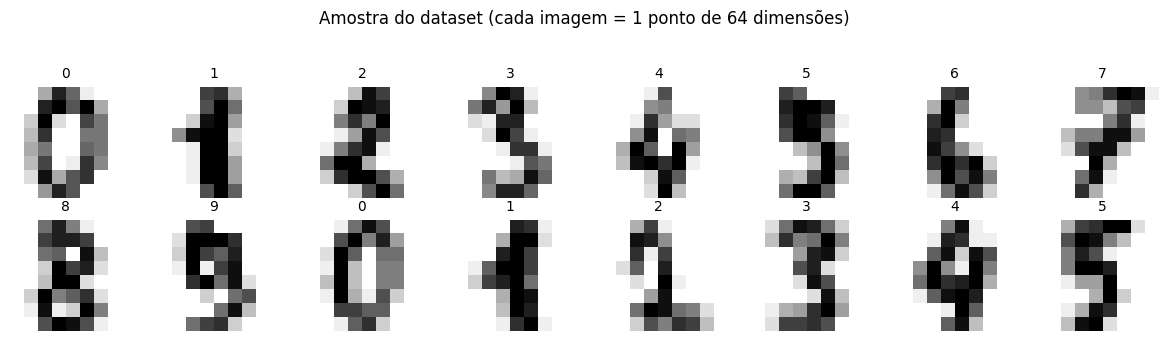

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap='gray_r'); ax.set_title(str(label), fontsize=10); ax.axis('off')
plt.suptitle('Amostra do dataset (cada imagem = 1 ponto de 64 dimensões)', y=1.05)
plt.tight_layout(); plt.show()

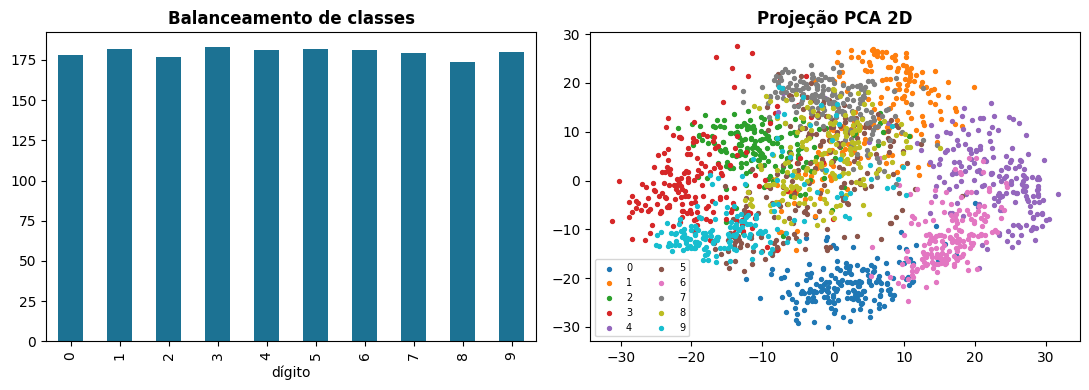

10 classes bem mais emaranhadas em 2D do que no Wine -- complexidade real, não só mais features.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pd.Series(digits.target).value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#1C7293')
axes[0].set_title('Balanceamento de classes', fontweight='bold')
axes[0].set_xlabel('dígito')

X_pca = PCA(n_components=2, random_state=42).fit_transform(digits.data)
for d in range(10):
    mask = digits.target == d
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, label=str(d))
axes[1].set_title('Projeção PCA 2D', fontweight='bold')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()
print('10 classes bem mais emaranhadas em 2D do que no Wine -- complexidade real, não só mais features.')

### E se a gente olhar o "dígito médio" de cada classe?

Em vez de olhar imagem por imagem, dá pra somar a informação de uma classe inteira:
a **média pixel a pixel** de todas as imagens do dígito `3`, por exemplo, é também
uma imagem 8×8 — um "protótipo" daquele dígito. Isso já é, em espírito, o que o
FEMa faz na hora de prever: uma combinação (ponderada) de vários pontos vizinhos.

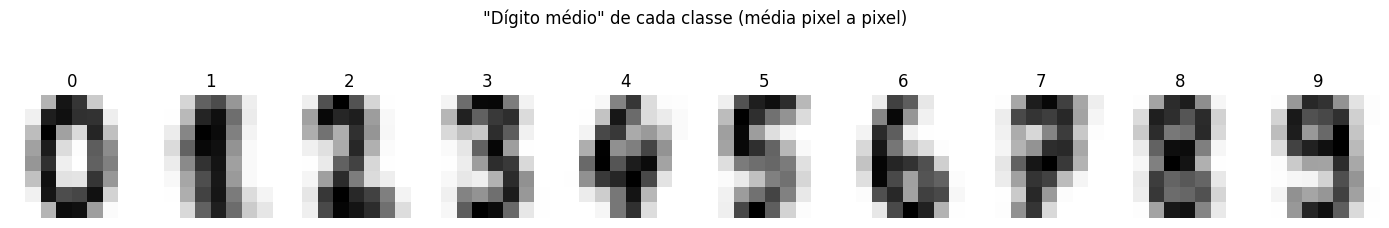

In [4]:
medias_por_classe = np.array([digits.data[digits.target == d].mean(axis=0) for d in range(10)])

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for d, ax in enumerate(axes):
    ax.imshow(medias_por_classe[d].reshape(8, 8), cmap='gray_r')
    ax.set_title(str(d)); ax.axis('off')
plt.suptitle('"Dígito médio" de cada classe (média pixel a pixel)', y=1.15)
plt.tight_layout(); plt.show()

### Quais dígitos são parecidos entre si? (sem treinar nenhum modelo ainda)

Se a gente mede a distância euclidiana entre esses 10 protótipos, já dá pra arriscar
um palpite de **quais pares o modelo provavelmente vai confundir mais** — antes mesmo
de rodar qualquer coisa. Guarda esse palpite: vamos comparar com a matriz de confusão
de verdade lá no final do dia.

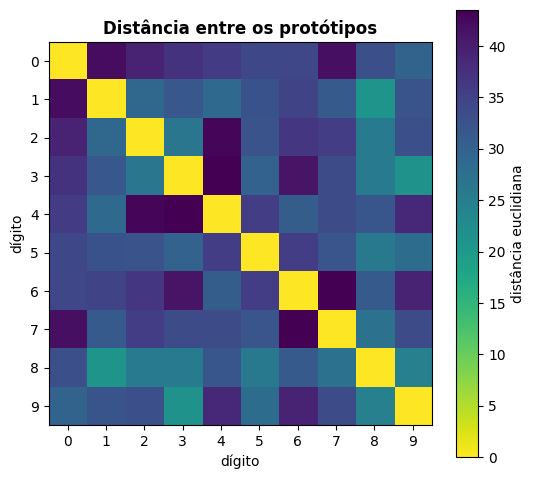

Pares de dígitos mais parecidos (menor distância entre protótipos):
  1 <-> 8: distância = 21.0
  3 <-> 9: distância = 21.1
  8 <-> 9: distância = 24.6
  3 <-> 8: distância = 25.5
  2 <-> 8: distância = 25.6


In [5]:
from scipy.spatial.distance import cdist

D_protos = cdist(medias_por_classe, medias_por_classe)
D_sem_diagonal = D_protos.copy()
np.fill_diagonal(D_sem_diagonal, np.inf)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(D_protos, cmap='viridis_r')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('dígito'); ax.set_ylabel('dígito')
ax.set_title('Distância entre os protótipos', fontweight='bold')
plt.colorbar(im, label='distância euclidiana')
plt.tight_layout(); plt.show()

pares = [(D_sem_diagonal[i, j], i, j) for i in range(10) for j in range(i + 1, 10)]
pares.sort()
print('Pares de dígitos mais parecidos (menor distância entre protótipos):')
for d, i, j in pares[:5]:
    print(f'  {i} <-> {j}: distância = {d:.1f}')

## 2. Pré-processamento: da imagem ao vetor

Cada imagem 8×8 vira um vetor de **64 features** (uma por pixel) — é assim que
qualquer imagem entra num modelo baseado em distância. Antes de normalizar,
vale ver isso acontecendo de verdade:

In [6]:
indice = 0
imagem = digits.images[indice]      # matriz 8x8 (como a gente enxerga)
vetor = digits.data[indice]          # o MESMO dado, já achatado em 64 posições

print('Dígito:', digits.target[indice])
print('Como matriz 8x8 (o que a gente vê):')
print(imagem.astype(int))
print('\nComo vetor de 64 features (o que o modelo vê):')
print(vetor.astype(int))
print('\nShape da matriz:', imagem.shape, ' -> shape do vetor:', vetor.shape)

Dígito: 0
Como matriz 8x8 (o que a gente vê):
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]

Como vetor de 64 features (o que o modelo vê):
[ 0  0  5 13  9  1  0  0  0  0 13 15 10 15  5  0  0  3 15  2  0 11  8  0
  0  4 12  0  0  8  8  0  0  5  8  0  0  9  8  0  0  4 11  0  1 12  7  0
  0  2 14  5 10 12  0  0  0  0  6 13 10  0  0  0]

Shape da matriz: (8, 8)  -> shape do vetor: (64,)


### Será que normalizar (como no Dia 1) ajuda aqui?

No Dia 1, idade e renda estavam em escalas completamente diferentes (0–100 vs.
0–50.000) — por isso a normalização era obrigatória. Aqui, as 64 features são
todas a **mesma coisa** (intensidade de pixel, 0 a 16) — então, a priori, a
diferença de escala não existe do mesmo jeito. Será que normalizar ainda ajuda?
Vamos testar em vez de assumir:

- **bruto**: pixels como vêm (0–16), sem nenhuma transformação
- **z-score**: a normalização padrão usada o curso inteiro
- **PCA (20 componentes) + z-score**: reduz as 64 features pra 20 "supercombinações"
  de pixels antes de normalizar — menos dimensões pra buscar vizinhos (vantagem de
  performance, ligado ao ponto de "estruturas espaciais" dos próximos passos)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

X_raw = digits.data
X_zscore = StandardScaler().fit_transform(digits.data)
X_pca20 = StandardScaler().fit_transform(PCA(n_components=20, random_state=42).fit_transform(digits.data))

modelo_fixo = FEMaClassifier(basis='shepard', basis_kwargs={'z': 2.0}, k=15)  # config fixa, só pra isolar o efeito do pré-processamento

variantes = {'bruto (0-16)': X_raw, 'z-score (64 dims)': X_zscore, 'PCA 20 + z-score': X_pca20}
resultado = {}
for nome, Xv in variantes.items():
    scores = cross_val_score(modelo_fixo, Xv, digits.target, cv=5, scoring='f1_macro')
    resultado[nome] = {'F1 médio (5-fold)': scores.mean(), 'Desvio padrão': scores.std()}

results_table(resultado)

,F1 médio (5-fold),Desvio padrão
bruto (0-16),0.9589,0.0121
z-score (64 dims),0.9425,0.0142
PCA 20 + z-score,0.9440,0.0200


**O que isso mostra:** diferente do exemplo idade/renda do Dia 1, aqui normalizar não é
obrigatório — as 64 features já nascem na mesma escala. Ainda assim, seguimos usando
z-score daqui pra frente (é o padrão de `load_classification_dataset`, e a diferença
aqui é pequena) — o ponto é: **sempre teste a suposição, não aplique normalização
por hábito**. O PCA (20 componentes) perde pouquíssimo desempenho usando quase 1/3
das dimensões — guarde essa ideia para quando a busca por vizinhos (força bruta)
começar a pesar em bases maiores.

In [8]:
X_train, X_test, y_train, y_test, _ = load_classification_dataset('digits', scale=True)
print('Treino:', X_train.shape, '| Teste:', X_test.shape)

Treino: (1257, 64) | Teste: (540, 64)


## 3. Qual função de base funciona melhor aqui? (tuning simples)

In [9]:
gs = GridSearchCV(FEMaClassifier(), {'basis': list(BASIS_FUNCTIONS), 'k': [5, 10, 20]}, cv=5, scoring='f1_macro', n_jobs=-1)
gs.fit(X_train, y_train)
print('Melhor configuração:', gs.best_params_)
print('Melhor F1 (CV):', round(gs.best_score_, 4))

Melhor configuração: {'basis': 'shepard', 'k': 10}
Melhor F1 (CV): 0.9738


## 4. Comparando com KNN e Regressão Logística

In [10]:
modelos = {
    'FEMa (melhor config.)': gs.best_estimator_,
    'KNN ponderado':          KNNClassifier(k=10, weighting='distance'),
    'Regressão Logística':    LogisticRegression(max_iter=3000),
}

linhas = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1_macro')
    linhas[nome] = {'F1 médio (5-fold)': scores.mean(), 'Desvio padrão': scores.std()}

results_table(linhas)

,F1 médio (5-fold),Desvio padrão
FEMa (melhor config.),0.9738,0.0089
KNN ponderado,0.9707,0.0097
Regressão Logística,0.9655,0.0097


## 5. Avaliação final no conjunto de teste

Acurácia              : 0.9704
Acurácia balanceada   : 0.9700
Precisão              : 0.9711
Recall                : 0.9700
F1-score              : 0.9700
AUC-ROC               : 0.9954


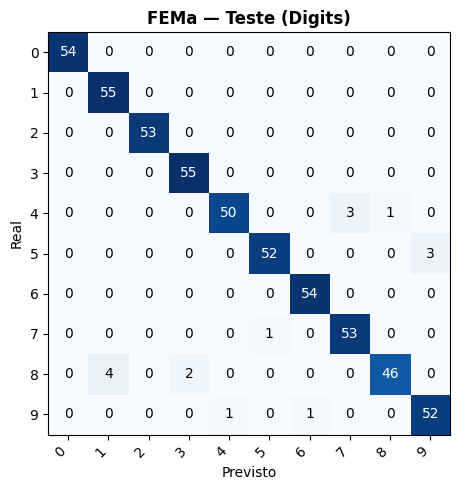

In [11]:
melhor_modelo = gs.best_estimator_.fit(X_train, y_train)
y_pred = melhor_modelo.predict(X_test)
y_proba = melhor_modelo.predict_proba(X_test)

relatorio = classification_report_dict(y_test, y_pred, y_proba, average='macro')
for metrica, valor in relatorio.items():
    print(f'{metrica:22s}: {valor:.4f}')

cm, labels = confusion(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm, labels, ax=ax, title='FEMa — Teste (Digits)')
plt.tight_layout(); plt.show()

---
**Próximos passos (fora do escopo de hoje):**
- **Verificação estatística** (Friedman + Wilcoxon + Holm, igual ao pôster): aqui comparamos médias de F1 — pra afirmar que uma função de base é de fato melhor, falta testar se a diferença é estatisticamente significativa.
- **Estruturas de dados espaciais** (KD-Tree/Ball-Tree): com 1.797 pontos a busca por força bruta já se sente mais lenta — numa base maior, isso passa a importar de verdade.
